# Hierarchical Multi-Label Classification Model  -  Configurable
This notebook provides a highly configurable framework for training hierarchical or flat multi-label classification models on the HRAF misfortune dataset. All key parameters can be adjusted in Cell 2 without modifying the core code.

To use this notebook:

- Set your experiment name in Cell 2's EXPERIMENT_CONFIG to track different runs (these will be saved in results folder inside the current directory)
- Configure the model architecture in CONFIG: choose hierarchical vs flat, enable/disable gating, select loss functions (weighted vs focal), and adjust model capacity
- Enable/disable specific labels by commenting them in/out in LABEL_STRUCTURE
- Adjust training parameters like epochs, learning rate, and batch size in TRAINING_CONFIG
- Run all cells to train - results automatically save to ./results/your_experiment_name/
- Cell 17 provides a quick inference test - You can replace the "test_text" to see the model's predictions.
- For a full inference eval, use the inference_testing.ipynb notebook.


In [45]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    AutoTokenizer,
    PreTrainedModel,
    PretrainedConfig,
    AutoModel,
    AutoConfig,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from typing import Optional, Dict, List
import warnings
import os
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [46]:
# ============================================================================
# CELL 2: CONFIGURATION PARAMETERS
# ============================================================================

# -------------------------------------------------------------------------
# EXPERIMENT NAMING
# -------------------------------------------------------------------------
EXPERIMENT_CONFIG = {
    # Change this name for each experiment to save results separately
    "experiment_name": "Test for Huggingface registry",  # e.g., "focal_loss_test", "no_gating", "lower_threshold"

    # Automatically generate name based on key settings
    "auto_name": False,  # If True, will auto-generate name from settings
}

# -------------------------------------------------------------------------
# MODEL ARCHITECTURE PARAMETERS
# -------------------------------------------------------------------------
CONFIG = {
    # Base transformer model (can be changed to distilbert-base-uncased, roberta-base, bert-base, etc.)
    "base_model": "roberta-base",

    # Hierarchical architecture settings
    "use_hierarchy": True,  # If False, treats as independent multi-label (Flat model), If True the model thinks in steps ("Is there an event?" then "What kind of event?").
    "gated_hierarchy": True,  # If True, sublabels are only predicted when main label is positive; If False sublabels are classified independently with main category predictions as input.
    "gate_threshold": 0.3,  # Threshold for gating (when main label probability enables sublabel - higher threshold means stricter gating)

    # Hidden layer sizes
    "hidden_size": 768,  # Don't change unless trying a larger model. This is correct for the models you are working with.
    "hierarchical_hidden_size": 265,   # Could be 50, 256, 512, etc., adjust this to give the model more "thinking space". Higher numbers could help with the model pick up nuances, too high could lead to "over-thinking"
    "num_hidden_layers": 2,  # How many layers (steps) more (3) could lead to overfitting (memorizing rather than learning); less (1) might miss complex patterns - but might also help compensate for the noisy data

    # Regularization
    "dropout": 0.2, # this randomly blocks % of model parameters to prevent overfitting and force. Helps prevent the mnodel from learning the quirks and biases of the RAs
    "attention_dropout": 0.1, # This randomly deletes a % of word relationships keeping the model from over relying on any single parameter too heavily

    # Loss function settings - Currently, we shouldn't set both use_weighted_loss and use_focal_loss to True.
    "use_weighted_loss": False,  # Use class weights for imbalanced data (Rare labels like Action:Priest_High_Religion are weighted more heavily) If True, each label gets a multiplier based on rarity. Loss = weight × prediction_error
    "use_focal_loss": True,  # Alternative to weighted BCE for extreme imbalance. Sets a dynamic weight based on model's confidence.
    "focal_gamma": 2.5,  # Adjusts the time the model focuses on hard examples vs easy ones
    # gamma = 0    → All examples equal (regular cross-entropy)
    # gamma = 0.5  → Slight focus on errors
    # gamma = 1.0  → Moderate focus
    # gamma = 2.0  → Standard focal loss (most common)
    # gamma = 2.5  → Aggressive focusing (good for extreme imbalance)
    # gamma = 3.0  → Very aggressive (might underfit)
    # gamma = 5.0  → Extreme (probably too much)

    # Teacher forcing (during training) -
    "teacher_forcing_ratio": 0.7,  # Probability of using true labels vs predictions
    # We might want to add gradual reduction for teacher forcing. We Start high (.8) and decrease over epochs (.5 - .3)
}

# -------------------------------------------------------------------------
# LABEL STRUCTURE (Sublabels can be commented out to ignore)
# -------------------------------------------------------------------------
LABEL_STRUCTURE = {
    "EVENT": {
        "main_label": "EVENT",
        "sublabels": [
            "EVENT_Illness",
            "EVENT_Accident",
            # "EVENT_Other"
        ],
        "enabled": True
    },
    "CAUSE": {
        "main_label": "CAUSE",
        "sublabels": [
            # "CAUSE_Just_Happens",
            "CAUSE_Material_Physical",
            "CAUSE_Spirits_Gods",
            "CAUSE_Witchcraft_Sorcery",
            "CAUSE_Rule_Violation_Taboo",
            # "CAUSE_Other"
        ],
        "enabled": True
    },
    "ACTION": {
        "main_label": "ACTION",
        "sublabels": [
            "ACTION_Physical_Material",
            "ACTION_Technical_Specialist",
            # "ACTION_Divination",
            "ACTION_Shaman_Medium_Healer",
            # "ACTION_Priest_High_Religion",
            # "ACTION_Other"
        ],
        "enabled": True
    }
}

# "Other" sublabels could fill up with heterogeneous examples making it hard for the model to learn consistent patterns

# -------------------------------------------------------------------------
# TRAINING PARAMETERS
# -------------------------------------------------------------------------

TRAINING_CONFIG = {
    "num_epochs": 15, # How many times to see the entire dataset; Too few = underlearning, too many = memorizing the noise
    "batch_size": 16, # Passages processed together - larger is more stable but needs more memory
    "gradient_accumulation_steps": 1, # Update weights every X batches (this has a multiplier effect on batch size - we could try "batch_size": 8 & "gradient_accumulation_steps": 2
    "learning_rate": 2e-5, # How big steps to take (0.00002), slower steps are probably best for the noisy data
    "warmup_steps": 500, # Gentle start for 500 steps, This prevents wild adjustments early on - but we could increase to 700-1000 with a golden data set
    "weight_decay": 0.01, # this prevents overfitting with a penalty for large weights. We could try .02
    "max_length": 512, # token length (limit for the models we are using)
    "eval_steps": 100, # Check performance every X steps
    "save_steps": 500, # Save model checkpoint
    "logging_steps": 50, # Write to logs
    "early_stopping_patience": 3, # Stop if no improvement for X evaluation rounds
    "label_smoothing": 0.1,  # Helps avoid overconfident predictions by adding a percentage of doubt (Label says EVENT=1 → Model learns EVENT=0.9; Label says EVENT=0 → Model learns EVENT=0.1) This will help with noisy data that may have incorrect or inconsistent labels.
}

# -------------------------------------------------------------------------
# DATA PARAMETERS
# -------------------------------------------------------------------------
DATA_CONFIG = {
    "excel_path": "_test_dataset.xlsx", # source of training data
    "test_size": 0.2, # percentage of data set reserved for final testing
    "validation_size": 0.1,  # percentage of data used to stop training and detect overfitting
    "random_seed": 42, # the answer to the ultimate question of life, the universe, and everything - Don't Change This!
    "stratify_by": "EVENT",  # Which main label to stratify split by (EVENT is the most common label - but we could also try multilabel stratification: ["EVENT", "CAUSE", "ACTION"]; or even by a rare label [stratify_by": "CAUSE_Witchcraft_Sorcery"]. We might even consider a custom stratification that all labels appear in each split. I don't think Scikit-learn supports this.
}

print("Configuration loaded successfully!")
print(f"Hierarchy: {'ENABLED' if CONFIG['use_hierarchy'] else 'DISABLED'}")
print(f"Gated: {'YES' if CONFIG['gated_hierarchy'] else 'NO'}")
print(f"Base Model: {CONFIG['base_model']}")

Configuration loaded successfully!
Hierarchy: ENABLED
Gated: YES
Base Model: roberta-base


In [47]:
# ============================================================================
# CELL 3: CALCULATE LABEL DIMENSIONS
# ============================================================================

def calculate_label_dimensions(label_structure):
    """Calculate the number of labels for each category"""
    dims = {
        "num_main_labels": 0,
        "num_event_labels": 0,
        "num_cause_labels": 0,
        "num_action_labels": 0,
        "total_labels": 0,
        "label_indices": {},
        "label_names": []
    }

    current_idx = 0

    # Process each category
    for category, info in label_structure.items():
        if not info["enabled"]:
            continue

        # Main label
        dims["num_main_labels"] += 1
        dims["label_indices"][info["main_label"]] = current_idx
        dims["label_names"].append(info["main_label"])
        current_idx += 1

    # Sublabels
    for category, info in label_structure.items():
        if not info["enabled"]:
            continue

        for sublabel in info["sublabels"]:
            if category == "EVENT":
                dims["num_event_labels"] += 1
            elif category == "CAUSE":
                dims["num_cause_labels"] += 1
            elif category == "ACTION":
                dims["num_action_labels"] += 1

            dims["label_indices"][sublabel] = current_idx
            dims["label_names"].append(sublabel)
            current_idx += 1

    dims["total_labels"] = current_idx

    return dims

LABEL_DIMS = calculate_label_dimensions(LABEL_STRUCTURE)
print(f"Label dimensions calculated:")
print(f"  Main labels: {LABEL_DIMS['num_main_labels']}")
print(f"  Event sublabels: {LABEL_DIMS['num_event_labels']}")
print(f"  Cause sublabels: {LABEL_DIMS['num_cause_labels']}")
print(f"  Action sublabels: {LABEL_DIMS['num_action_labels']}")
print(f"  Total labels: {LABEL_DIMS['total_labels']}")

Label dimensions calculated:
  Main labels: 3
  Event sublabels: 2
  Cause sublabels: 4
  Action sublabels: 3
  Total labels: 12


In [48]:
# ============================================================================
# CELL 4: MODEL DEFINITION WITH HUGGING FACE COMPATIBILITY (UPDATED)
# ============================================================================

from transformers import AutoModel, AutoConfig
from transformers.models.auto import auto_factory

class ConfigurableHierarchicalConfig(PretrainedConfig):
    """Configuration for configurable hierarchical model"""
    model_type = "configurable_hierarchical"

    def __init__(
        self,
        base_model="roberta-base",
        use_hierarchy=True,
        gated_hierarchy=True,
        gate_threshold=0.5,
        hidden_size=768,
        hierarchical_hidden_size=256,
        num_hidden_layers=2,
        dropout=0.2,
        attention_dropout=0.1,
        use_weighted_loss=False,
        use_focal_loss=True,
        focal_gamma=2.5,
        teacher_forcing_ratio=0.7,
        num_main_labels=3,
        num_event_labels=2,
        num_cause_labels=4,
        num_action_labels=3,
        total_labels=12,
        label_indices=None,
        label_names=None,
        **kwargs
    ):
        super().__init__(**kwargs)

        # Model architecture parameters
        self.base_model = base_model
        self.use_hierarchy = use_hierarchy
        self.gated_hierarchy = gated_hierarchy
        self.gate_threshold = gate_threshold
        self.hidden_size = hidden_size
        self.hierarchical_hidden_size = hierarchical_hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.dropout = dropout
        self.attention_dropout = attention_dropout

        # Training parameters
        self.use_weighted_loss = use_weighted_loss
        self.use_focal_loss = use_focal_loss
        self.focal_gamma = focal_gamma
        self.teacher_forcing_ratio = teacher_forcing_ratio

        # Label dimensions
        self.num_main_labels = num_main_labels
        self.num_event_labels = num_event_labels
        self.num_cause_labels = num_cause_labels
        self.num_action_labels = num_action_labels
        self.total_labels = total_labels
        self.label_indices = label_indices or {}
        self.label_names = label_names or []


class ConfigurableHierarchicalModel(PreTrainedModel):
    """Highly configurable hierarchical multi-label classifier"""
    config_class = ConfigurableHierarchicalConfig
    base_model_prefix = "configurable_hierarchical"
    supports_gradient_checkpointing = True

    def __init__(self, config: ConfigurableHierarchicalConfig):
        super().__init__(config)

        # Store config
        self.config = config

        # Load base encoder
        self.encoder = AutoModel.from_pretrained(config.base_model)

        # Apply additional dropout to encoder if specified
        if hasattr(config, 'attention_dropout') and config.attention_dropout > 0:
            self.encoder.config.attention_probs_dropout_prob = config.attention_dropout

        # Main classifiers (always present)
        self.main_classifier = nn.Linear(config.hidden_size, config.num_main_labels)

        # Build sublabel classifiers based on configuration
        if config.use_hierarchy:
            # Hierarchical: sublabels depend on main labels
            hierarchical_input_size = config.hidden_size + config.num_main_labels
        else:
            # Non-hierarchical: sublabels independent
            hierarchical_input_size = config.hidden_size

        # Create sublabel classifiers with configurable depth
        self.event_classifier = self._build_sublabel_classifier(
            hierarchical_input_size,
            config.num_event_labels,
            config.hierarchical_hidden_size,
            config.num_hidden_layers,
            config.dropout
        )

        self.cause_classifier = self._build_sublabel_classifier(
            hierarchical_input_size,
            config.num_cause_labels,
            config.hierarchical_hidden_size,
            config.num_hidden_layers,
            config.dropout
        )

        self.action_classifier = self._build_sublabel_classifier(
            hierarchical_input_size,
            config.num_action_labels,
            config.hierarchical_hidden_size,
            config.num_hidden_layers,
            config.dropout
        )

        # Store config for forward pass
        self.use_hierarchy = config.use_hierarchy
        self.gated_hierarchy = config.gated_hierarchy
        self.gate_threshold = config.gate_threshold

        # Initialize weights
        self.post_init()

    def _build_sublabel_classifier(self, input_size, output_size, hidden_size, num_layers, dropout):
        """Build a sublabel classifier with configurable depth"""
        if output_size == 0:
            return None

        layers = []

        for i in range(num_layers):
            if i == 0:
                layers.append(nn.Linear(input_size, hidden_size))
            else:
                layers.append(nn.Linear(hidden_size, hidden_size))

            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_size, output_size))

        return nn.Sequential(*layers)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        teacher_forcing=False,
        return_dict=None,
        **kwargs
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # Get encoder outputs
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # Pool the outputs
        pooled_output = encoder_outputs.last_hidden_state[:, 0]

        # Get main predictions
        main_logits = self.main_classifier(pooled_output)

        if self.use_hierarchy:
            # Use main predictions for sublabel input
            if teacher_forcing and labels is not None:
                # During training, sometimes use true labels
                main_probs = labels[:, :self.config.num_main_labels].float()
            else:
                main_probs = torch.sigmoid(main_logits)

            hierarchical_input = torch.cat([pooled_output, main_probs], dim=1)
        else:
            # Non-hierarchical: use only pooled output
            hierarchical_input = pooled_output

        # Get sublabel predictions
        event_logits = self.event_classifier(hierarchical_input) if self.event_classifier else torch.zeros(main_logits.shape[0], 0).to(main_logits.device)
        cause_logits = self.cause_classifier(hierarchical_input) if self.cause_classifier else torch.zeros(main_logits.shape[0], 0).to(main_logits.device)
        action_logits = self.action_classifier(hierarchical_input) if self.action_classifier else torch.zeros(main_logits.shape[0], 0).to(main_logits.device)

        # Apply gating if configured
        if self.gated_hierarchy and self.use_hierarchy:
            main_probs = torch.sigmoid(main_logits)

            # Gate EVENT sublabels
            if event_logits.shape[1] > 0:
                event_gate = torch.where(
                    main_probs[:, 0:1] > self.gate_threshold,
                    torch.ones_like(main_probs[:, 0:1]),
                    torch.zeros_like(main_probs[:, 0:1])
                )
                event_logits = event_logits * event_gate

            # Gate CAUSE sublabels
            if cause_logits.shape[1] > 0:
                cause_gate = torch.where(
                    main_probs[:, 1:2] > self.gate_threshold,
                    torch.ones_like(main_probs[:, 1:2]),
                    torch.zeros_like(main_probs[:, 1:2])
                )
                cause_logits = cause_logits * cause_gate

            # Gate ACTION sublabels
            if action_logits.shape[1] > 0:
                action_gate = torch.where(
                    main_probs[:, 2:3] > self.gate_threshold,
                    torch.ones_like(main_probs[:, 2:3]),
                    torch.zeros_like(main_probs[:, 2:3])
                )
                action_logits = action_logits * action_gate

        # Concatenate all logits
        logits = torch.cat([
            main_logits, event_logits, cause_logits, action_logits
        ], dim=1)

        # Calculate loss if labels provided
        loss = None
        if labels is not None:
            if self.config.use_focal_loss and hasattr(self.config, 'focal_gamma'):
                loss = self._focal_loss(logits, labels.float(), gamma=self.config.focal_gamma)
            else:
                loss_fct = nn.BCEWithLogitsLoss()
                loss = loss_fct(logits, labels.float())

        if not return_dict:
            output = (logits,) + encoder_outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
        )

    def _focal_loss(self, logits, targets, gamma=2.0):
        """Focal loss for handling extreme class imbalance"""
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        probas = torch.sigmoid(logits)

        # Calculate focal weights
        focal_weight = torch.where(
            targets == 1,
            (1 - probas) ** gamma,
            probas ** gamma
        )

        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()

In [49]:
# ============================================================================
# CELL 5: REGISTER MODEL WITH HUGGING FACE
# ============================================================================

# Register the configuration
AutoConfig.register("configurable_hierarchical", ConfigurableHierarchicalConfig)

# Register the model
AutoModel.register(ConfigurableHierarchicalConfig, ConfigurableHierarchicalModel)

In [50]:
# ============================================================================
# CELL 6: DATA LOADING AND PREPROCESSING  - This can handle both xlsx or json files. Weights are automatically configured based on rarity
# ============================================================================

def load_and_preprocess_data(data_config, label_structure, label_dims):
    """Load and preprocess the dataset from Excel or JSON"""

    print("Loading dataset...")

    # Check file extension
    file_path = data_config["excel_path"]  # Can be Excel or JSON path

    if file_path.endswith('.json'):
        # =====================================================
        # JSON LOADING
        # =====================================================
        import json

        with open(file_path, 'r') as f:
            data = json.load(f)

        # Handle different JSON structures
        if isinstance(data, list):
            # List of objects format
            df_clean = pd.DataFrame(data)
        elif isinstance(data, dict):
            # Nested dictionary format
            if 'passages' in data:
                df_clean = pd.DataFrame(data['passages'])
            elif 'data' in data:
                df_clean = pd.DataFrame(data['data'])
            else:
                # Try to convert dict directly
                df_clean = pd.DataFrame.from_dict(data, orient='index')

        # Ensure required columns exist
        if 'passage' not in df_clean.columns and 'text' in df_clean.columns:
            df_clean['passage'] = df_clean['text']
        elif 'passage' not in df_clean.columns and 'Passage' in df_clean.columns:
            df_clean['passage'] = df_clean['Passage']

        if 'ID' not in df_clean.columns:
            df_clean['ID'] = range(len(df_clean))

        print(f"Loaded {len(df_clean)} passages from JSON")

    else:
        # =====================================================
        # EXCEL LOADING (Original Code)
        # =====================================================
        df = pd.read_excel(
            file_path,
            header=[0, 1],
            index_col=0
        )
        print(f"Initial passages: {len(df)}")

        # Clean duplicates
        mask_not_duplicate = ~df.duplicated(("CULTURE", "Passage"), keep=False)
        mask_run3 = df[("CODER", "Run_Number")] == 3
        df = df[mask_not_duplicate | mask_run3]
        df = df.drop_duplicates(subset=[("CULTURE", "Passage")], keep='last')

        # Remove problematic passages
        problematic_ids = [3252, 33681, 6758, 10104]
        if ('CULTURE', 'Passage Number') in df.columns:
            df = df[~df[('CULTURE', 'Passage Number')].isin(problematic_ids)]

        print(f"After cleaning: {len(df)} passages")

        # Extract relevant columns based on label structure
        df_clean = pd.DataFrame()
        df_clean['ID'] = df[('CULTURE', 'Passage Number')]
        df_clean['passage'] = df[('CULTURE', 'Passage')]

        # Map columns based on enabled labels
        for category, info in label_structure.items():
            if not info["enabled"]:
                continue

            # Main label (flip No_Info logic)
            main_col = (category, 'No_Info')
            if main_col in df.columns:
                df_clean[info["main_label"]] = df[main_col].replace({0: 1, 1: 0})

            # Sublabels
            for sublabel in info["sublabels"]:
                # Extract sublabel name after prefix
                sublabel_short = sublabel.split('_', 1)[1] if '_' in sublabel else sublabel

                # Try different column name formats
                possible_cols = [
                    (category, sublabel_short),
                    (category, sublabel_short.replace('_', ' ')),
                    (category, 'Material' if 'Physical_Material' in sublabel else sublabel_short)
                ]

                for col in possible_cols:
                    if col in df.columns:
                        df_clean[sublabel] = df[col]
                        break

    # =====================================================
    # COMMON PROCESSING FOR BOTH FORMATS
    # =====================================================

    # Fill NaN and convert to int
    df_clean = df_clean.fillna(0)
    label_columns = label_dims["label_names"]

    for col in label_columns:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(int)

    # Check for missing columns and add zeros
    for col in label_columns:
        if col not in df_clean.columns:
            print(f"Warning: {col} not found in data, adding zeros")
            df_clean[col] = 0

    print(f"Final dataset: {len(df_clean)} passages, {len(label_columns)} labels")

    # Calculate class weights for handling imbalance
    class_weights = []
    for col in label_columns:
        pos_count = df_clean[col].sum()
        neg_count = len(df_clean) - pos_count

        if pos_count > 0:
            weight = neg_count / pos_count
        else:
            weight = 1.0

        class_weights.append(weight)

        if weight > 10:  # Flag severely imbalanced classes
            print(f"⚠️ {col}: {pos_count}/{len(df_clean)} positive ({weight:.1f}x imbalanced)")

    return df_clean, label_columns, torch.tensor(class_weights).float()

# Load the data
df_clean, label_columns, class_weights = load_and_preprocess_data(
    DATA_CONFIG,
    LABEL_STRUCTURE,
    LABEL_DIMS
)

print(f"\nClass weights calculated (for weighted loss)")

Loading dataset...
Initial passages: 368
After cleaning: 368 passages
Final dataset: 368 passages, 12 labels
⚠️ EVENT_Accident: 13/368 positive (27.3x imbalanced)
⚠️ CAUSE_Witchcraft_Sorcery: 33/368 positive (10.2x imbalanced)
⚠️ ACTION_Technical_Specialist: 25/368 positive (13.7x imbalanced)
⚠️ ACTION_Shaman_Medium_Healer: 33/368 positive (10.2x imbalanced)

Class weights calculated (for weighted loss)


In [51]:
# ============================================================================
# CELL 7: CREATE TRAIN/VAL/TEST SPLITS
# ============================================================================

def create_data_splits(df_clean, label_columns, data_config):
    """Create train/validation/test splits"""

    # First split: train+val vs test
    train_val_df, test_df = train_test_split(
        df_clean,
        test_size=data_config["test_size"],
        random_state=data_config["random_seed"],
        stratify=df_clean[data_config["stratify_by"]] if data_config["stratify_by"] else None
    )

    # Second split: train vs val
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=data_config["validation_size"],
        random_state=data_config["random_seed"],
        stratify=train_val_df[data_config["stratify_by"]] if data_config["stratify_by"] else None
    )

    print(f"Data splits:")
    print(f"  Training: {len(train_df)} passages")
    print(f"  Validation: {len(val_df)} passages")
    print(f"  Test: {len(test_df)} passages")

    # Convert to HuggingFace datasets
    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
    test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = create_data_splits(
    df_clean,
    label_columns,
    DATA_CONFIG
)

Data splits:
  Training: 264 passages
  Validation: 30 passages
  Test: 74 passages


In [52]:
# ============================================================================
# CELL 8: TOKENIZATION AND DATASET PREPARATION
# ============================================================================

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"])

def tokenize_function(examples):
    """Tokenize the passages"""
    return tokenizer(
        examples['passage'],
        padding='max_length',
        truncation=True,
        max_length=TRAINING_CONFIG["max_length"]
    )

def prepare_labels(examples, label_columns):
    """Prepare label vectors in correct order"""
    labels = []
    batch_size = len(examples[label_columns[0]])

    for i in range(batch_size):
        label_vector = []
        for col in label_columns:
            label_vector.append(examples[col][i])
        labels.append(label_vector)

    examples['labels'] = labels
    return examples

# Apply tokenization
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Prepare labels
train_dataset = train_dataset.map(
    lambda x: prepare_labels(x, label_columns),
    batched=True
)
val_dataset = val_dataset.map(
    lambda x: prepare_labels(x, label_columns),
    batched=True
)
test_dataset = test_dataset.map(
    lambda x: prepare_labels(x, label_columns),
    batched=True
)

# Remove unnecessary columns
columns_to_remove = ['passage', 'ID'] + label_columns
train_dataset = train_dataset.remove_columns(
    [col for col in columns_to_remove if col in train_dataset.column_names]
)
val_dataset = val_dataset.remove_columns(
    [col for col in columns_to_remove if col in val_dataset.column_names]
)
test_dataset = test_dataset.remove_columns(
    [col for col in columns_to_remove if col in test_dataset.column_names]
)

# Set format
train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

print("✅ Datasets prepared and ready for training!")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: d2f8f82a-5cba-4a3f-a993-976b7c95be57)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


Tokenizing datasets...


Map:   0%|          | 0/264 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/74 [00:00<?, ? examples/s]

Map:   0%|          | 0/264 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/74 [00:00<?, ? examples/s]

✅ Datasets prepared and ready for training!


In [53]:
# ============================================================================
# CELL 9: CUSTOM TRAINER WITH TEACHER FORCING
# ============================================================================

class HierarchicalTrainer(Trainer):
    """Custom trainer with teacher forcing and weighted loss"""

    def __init__(self, class_weights=None, teacher_forcing_ratio=0.5, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.teacher_forcing_ratio = teacher_forcing_ratio

        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        """Custom loss computation with optional weighted loss

        Args:
            model: The model being trained
            inputs: Dictionary of inputs
            return_outputs: Whether to return outputs along with loss
            num_items_in_batch: Number of items in batch (for newer transformers versions)
            **kwargs: Additional arguments from newer transformers versions
        """
        labels = inputs.pop("labels")

        # Teacher forcing during training
        # Check if we're in training mode (model.training is more reliable)
        use_teacher_forcing = model.training and (torch.rand(1).item() < self.teacher_forcing_ratio)

        outputs = model(
            **inputs,
            labels=labels,
            teacher_forcing=use_teacher_forcing
        )

        # Custom weighted loss if class weights provided
        if self.class_weights is not None and CONFIG["use_weighted_loss"]:
            logits = outputs.logits
            weighted_bce = nn.BCEWithLogitsLoss(weight=self.class_weights)
            loss = weighted_bce(logits, labels.float())
        else:
            loss = outputs.loss

        return (loss, outputs) if return_outputs else loss

In [54]:
# ============================================================================
# CELL 10: EVALUATION METRICS
# ============================================================================

def compute_detailed_metrics(eval_pred, label_names):
    """Compute detailed metrics for each label"""
    predictions, labels = eval_pred

    # Apply sigmoid and threshold
    predictions = torch.sigmoid(torch.tensor(predictions)).numpy()
    predictions = np.where(predictions > 0.5, 1, 0)

    # Overall metrics
    f1_micro = f1_score(labels, predictions, average='micro', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)

    # Per-label metrics
    per_label_f1 = {}
    for i, name in enumerate(label_names):
        f1 = f1_score(labels[:, i], predictions[:, i], zero_division=0)
        per_label_f1[f"f1_{name}"] = f1

    # Main category averages
    main_f1s = [per_label_f1.get(f"f1_{name}", 0) for name in ["EVENT", "CAUSE", "ACTION"]]
    avg_main_f1 = np.mean([f for f in main_f1s if f > 0])

    return {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_main_avg': avg_main_f1,
        **per_label_f1
    }

# Create the metrics function for trainer
def compute_metrics(eval_pred):
    return compute_detailed_metrics(eval_pred, label_columns)

In [55]:
# ============================================================================
# CELL 11: INITIALIZE MODEL
# ============================================================================

# Create model configuration using the calculated dimensions
model_config = ConfigurableHierarchicalConfig(
    base_model=CONFIG["base_model"],
    use_hierarchy=CONFIG["use_hierarchy"],
    gated_hierarchy=CONFIG["gated_hierarchy"],
    gate_threshold=CONFIG["gate_threshold"],
    hidden_size=CONFIG["hidden_size"],
    hierarchical_hidden_size=CONFIG["hierarchical_hidden_size"],
    num_hidden_layers=CONFIG["num_hidden_layers"],
    dropout=CONFIG["dropout"],
    attention_dropout=CONFIG["attention_dropout"],
    use_weighted_loss=CONFIG["use_weighted_loss"],
    use_focal_loss=CONFIG["use_focal_loss"],
    focal_gamma=CONFIG["focal_gamma"],
    teacher_forcing_ratio=CONFIG["teacher_forcing_ratio"],
    num_main_labels=LABEL_DIMS["num_main_labels"],
    num_event_labels=LABEL_DIMS["num_event_labels"],
    num_cause_labels=LABEL_DIMS["num_cause_labels"],
    num_action_labels=LABEL_DIMS["num_action_labels"],
    total_labels=LABEL_DIMS["total_labels"],
    label_indices=LABEL_DIMS["label_indices"],
    label_names=LABEL_DIMS["label_names"]
)

# Initialize model
model = ConfigurableHierarchicalModel(model_config)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized!")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Hierarchy: {'ENABLED' if CONFIG['use_hierarchy'] else 'DISABLED'}")
print(f"  Gated: {'YES' if CONFIG['gated_hierarchy'] else 'NO'}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model initialized!
  Total parameters: 125,475,543
  Trainable parameters: 125,475,543
  Hierarchy: ENABLED
  Gated: YES


In [56]:
# ============================================================================
# CELL 12: TRAINING CONFIGURATION (UPDATED)
# ============================================================================

# Generate output directory name based on experiment configuration
def generate_output_dir_name():
    """Generate output directory name based on experiment settings"""

    if not EXPERIMENT_CONFIG.get("auto_name", False) and EXPERIMENT_CONFIG.get("experiment_name"):
        # Use the provided experiment name
        base_name = EXPERIMENT_CONFIG["experiment_name"]
    else:
        # Auto-generate name from key settings
        name_parts = []

        # Add architecture type
        if CONFIG["use_hierarchy"]:
            if CONFIG["gated_hierarchy"]:
                name_parts.append("hierarchical_gated")
            else:
                name_parts.append("hierarchical_ungated")
        else:
            name_parts.append("flat")

        # Add loss type
        if CONFIG["use_focal_loss"]:
            name_parts.append(f"focal_{CONFIG['focal_gamma']}")
        elif CONFIG["use_weighted_loss"]:
            name_parts.append("weighted")

        # Add key hyperparameters
        name_parts.append(f"lr_{TRAINING_CONFIG['learning_rate']}")
        name_parts.append(f"epochs_{TRAINING_CONFIG['num_epochs']}")

        # Add timestamp for uniqueness
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        name_parts.append(timestamp)

        base_name = "_".join(name_parts)

    # Sanitize the name for filesystem
    import re
    safe_name = re.sub(r'[^\w\-_\.]', '_', base_name)
    safe_name = re.sub(r'_+', '_', safe_name)  # Replace multiple underscores with single
    safe_name = safe_name.strip('_')  # Remove leading/trailing underscores

    return f"./results/{safe_name}"

# Generate output directory
output_dir = generate_output_dir_name()

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

print(f"Output directory: {output_dir}")

# Save experiment configuration to the output directory immediately
experiment_info = {
    "experiment_name": EXPERIMENT_CONFIG.get("experiment_name", "unnamed"),
    "auto_generated_name": EXPERIMENT_CONFIG.get("auto_name", False),
    "output_dir": output_dir,
    "timestamp": datetime.now().isoformat(),
    "config": CONFIG,
    "training_config": TRAINING_CONFIG,
    "data_config": DATA_CONFIG,
    "label_structure": LABEL_STRUCTURE
}

with open(f"{output_dir}/experiment_info.json", "w") as f:
    json.dump(experiment_info, f, indent=2)

print(f"Experiment configuration saved to: {output_dir}/experiment_info.json")

# Rest of the training configuration remains the same
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=TRAINING_CONFIG["num_epochs"],
    per_device_train_batch_size=TRAINING_CONFIG["batch_size"],
    per_device_eval_batch_size=TRAINING_CONFIG["batch_size"],
    gradient_accumulation_steps=TRAINING_CONFIG["gradient_accumulation_steps"],
    warmup_steps=TRAINING_CONFIG["warmup_steps"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
    learning_rate=TRAINING_CONFIG["learning_rate"],
    logging_dir=f'{output_dir}/logs',
    logging_steps=TRAINING_CONFIG["logging_steps"],
    eval_strategy="steps",
    eval_steps=TRAINING_CONFIG["eval_steps"],
    save_strategy="steps",
    save_steps=TRAINING_CONFIG["save_steps"],
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_micro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    label_smoothing_factor=TRAINING_CONFIG["label_smoothing"],
    remove_unused_columns=False,
)

# Initialize trainer
trainer = HierarchicalTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights if CONFIG["use_weighted_loss"] else None,
    teacher_forcing_ratio=CONFIG["teacher_forcing_ratio"],
)

print(f"Trainer configured!")
print(f"  Output directory: {output_dir}")
print(f"  Training for {TRAINING_CONFIG['num_epochs']} epochs")

Output directory: ./results/Test_for_Huggingface_registry
Experiment configuration saved to: ./results/Test_for_Huggingface_registry/experiment_info.json
Trainer configured!
  Output directory: ./results/Test_for_Huggingface_registry
  Training for 15 epochs


In [57]:
# ============================================================================
# CELL 13: TRAIN THE MODEL
# ============================================================================

print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)

# Train
trainer.train()

print("\n✅ Training completed!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


STARTING TRAINING


Step,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Main Avg,F1 Event,F1 Cause,F1 Action,F1 Event Illness,F1 Event Accident,F1 Cause Material Physical,F1 Cause Spirits Gods,F1 Cause Witchcraft Sorcery,F1 Cause Rule Violation Taboo,F1 Action Physical Material,F1 Action Technical Specialist,F1 Action Shaman Medium Healer
100,0.116300,0.115236,0.620879,0.389543,0.849123,0.947368,0.800000,0.800000,0.723404,0.000000,0.000000,0.378378,0.066667,0.235294,0.723404,0.000000,0.000000
200,0.095600,0.096047,0.733068,0.353095,0.836060,0.947368,0.750000,0.810811,0.723404,0.000000,0.000000,0.250000,0.000000,0.000000,0.755556,0.000000,0.000000



✅ Training completed!


In [58]:
# ============================================================================
# CELL 14: EVALUATE ON TEST SET
# ============================================================================

print("=" * 60)
print("EVALUATING ON TEST SET")
print("=" * 60)

# Evaluate on test set
test_results = trainer.evaluate(eval_dataset=test_dataset)

# Print results
print("\n📊 Test Set Results:")
print(f"  Overall F1 Micro: {test_results['eval_f1_micro']:.4f}")
print(f"  Overall F1 Macro: {test_results['eval_f1_macro']:.4f}")
print(f"  Main Categories Avg F1: {test_results['eval_f1_main_avg']:.4f}")

# Print top and bottom performing labels
label_f1s = [(k.replace('eval_f1_', ''), v) for k, v in test_results.items() if k.startswith('eval_f1_') and k not in ['eval_f1_micro', 'eval_f1_macro', 'eval_f1_main_avg']]
label_f1s.sort(key=lambda x: x[1], reverse=True)

print("\n🏆 Top 5 performing labels:")
for label, f1 in label_f1s[:5]:
    print(f"  {label}: {f1:.4f}")

print("\n⚠️ Bottom 5 performing labels:")
for label, f1 in label_f1s[-5:]:
    print(f"  {label}: {f1:.4f}")

EVALUATING ON TEST SET



📊 Test Set Results:
  Overall F1 Micro: 0.7241
  Overall F1 Macro: 0.3415
  Main Categories Avg F1: 0.8622

🏆 Top 5 performing labels:
  EVENT: 0.9559
  CAUSE: 0.8350
  EVENT_Illness: 0.7966
  ACTION: 0.7957
  ACTION_Physical_Material: 0.7143

⚠️ Bottom 5 performing labels:
  CAUSE_Spirits_Gods: 0.0000
  CAUSE_Witchcraft_Sorcery: 0.0000
  CAUSE_Rule_Violation_Taboo: 0.0000
  ACTION_Technical_Specialist: 0.0000
  ACTION_Shaman_Medium_Healer: 0.0000


In [59]:
# ============================================================================
# CELL 15: ANALYZE PREDICTIONS WITH DIFFERENT THRESHOLDS
# ============================================================================

def analyze_thresholds(model, dataset, label_names, thresholds=[0.3, 0.4, 0.5, 0.6, 0.7]):
    """Analyze performance at different prediction thresholds"""

    print("Analyzing optimal thresholds per label...")

    # Get predictions
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    labels = predictions.label_ids

    # Convert to probabilities
    probs = torch.sigmoid(torch.tensor(logits)).numpy()

    # Find optimal threshold per label
    optimal_thresholds = {}

    for i, label_name in enumerate(label_names):
        best_f1 = 0
        best_threshold = 0.5

        for threshold in thresholds:
            preds = np.where(probs[:, i] > threshold, 1, 0)
            f1 = f1_score(labels[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold

        optimal_thresholds[label_name] = {
            'threshold': best_threshold,
            'f1': best_f1,
            'default_f1': f1_score(labels[:, i], np.where(probs[:, i] > 0.5, 1, 0), zero_division=0)
        }

    # Print results
    print("\nOptimal thresholds (vs default 0.5):")
    improvements = []

    for label_name, info in optimal_thresholds.items():
        improvement = info['f1'] - info['default_f1']
        improvements.append(improvement)

        if abs(improvement) > 0.05:  # Significant difference
            print(f"  {label_name}: {info['threshold']:.1f} "
                  f"(F1: {info['f1']:.3f} vs {info['default_f1']:.3f}, "
                  f"{'↑' if improvement > 0 else '↓'}{abs(improvement):.3f})")

    print(f"\nAverage improvement with optimized thresholds: {np.mean(improvements):.4f}")

    return optimal_thresholds

# Analyze thresholds
optimal_thresholds = analyze_thresholds(model, test_dataset, label_columns)

Analyzing optimal thresholds per label...

Optimal thresholds (vs default 0.5):
  EVENT_Accident: 0.3 (F1: 0.127 vs 0.000, ↑0.127)
  CAUSE_Material_Physical: 0.3 (F1: 0.505 vs 0.000, ↑0.505)
  CAUSE_Spirits_Gods: 0.3 (F1: 0.474 vs 0.000, ↑0.474)
  CAUSE_Witchcraft_Sorcery: 0.4 (F1: 0.130 vs 0.000, ↑0.130)
  CAUSE_Rule_Violation_Taboo: 0.3 (F1: 0.217 vs 0.000, ↑0.217)
  ACTION_Technical_Specialist: 0.3 (F1: 0.173 vs 0.000, ↑0.173)
  ACTION_Shaman_Medium_Healer: 0.3 (F1: 0.127 vs 0.000, ↑0.127)

Average improvement with optimized thresholds: 0.1494


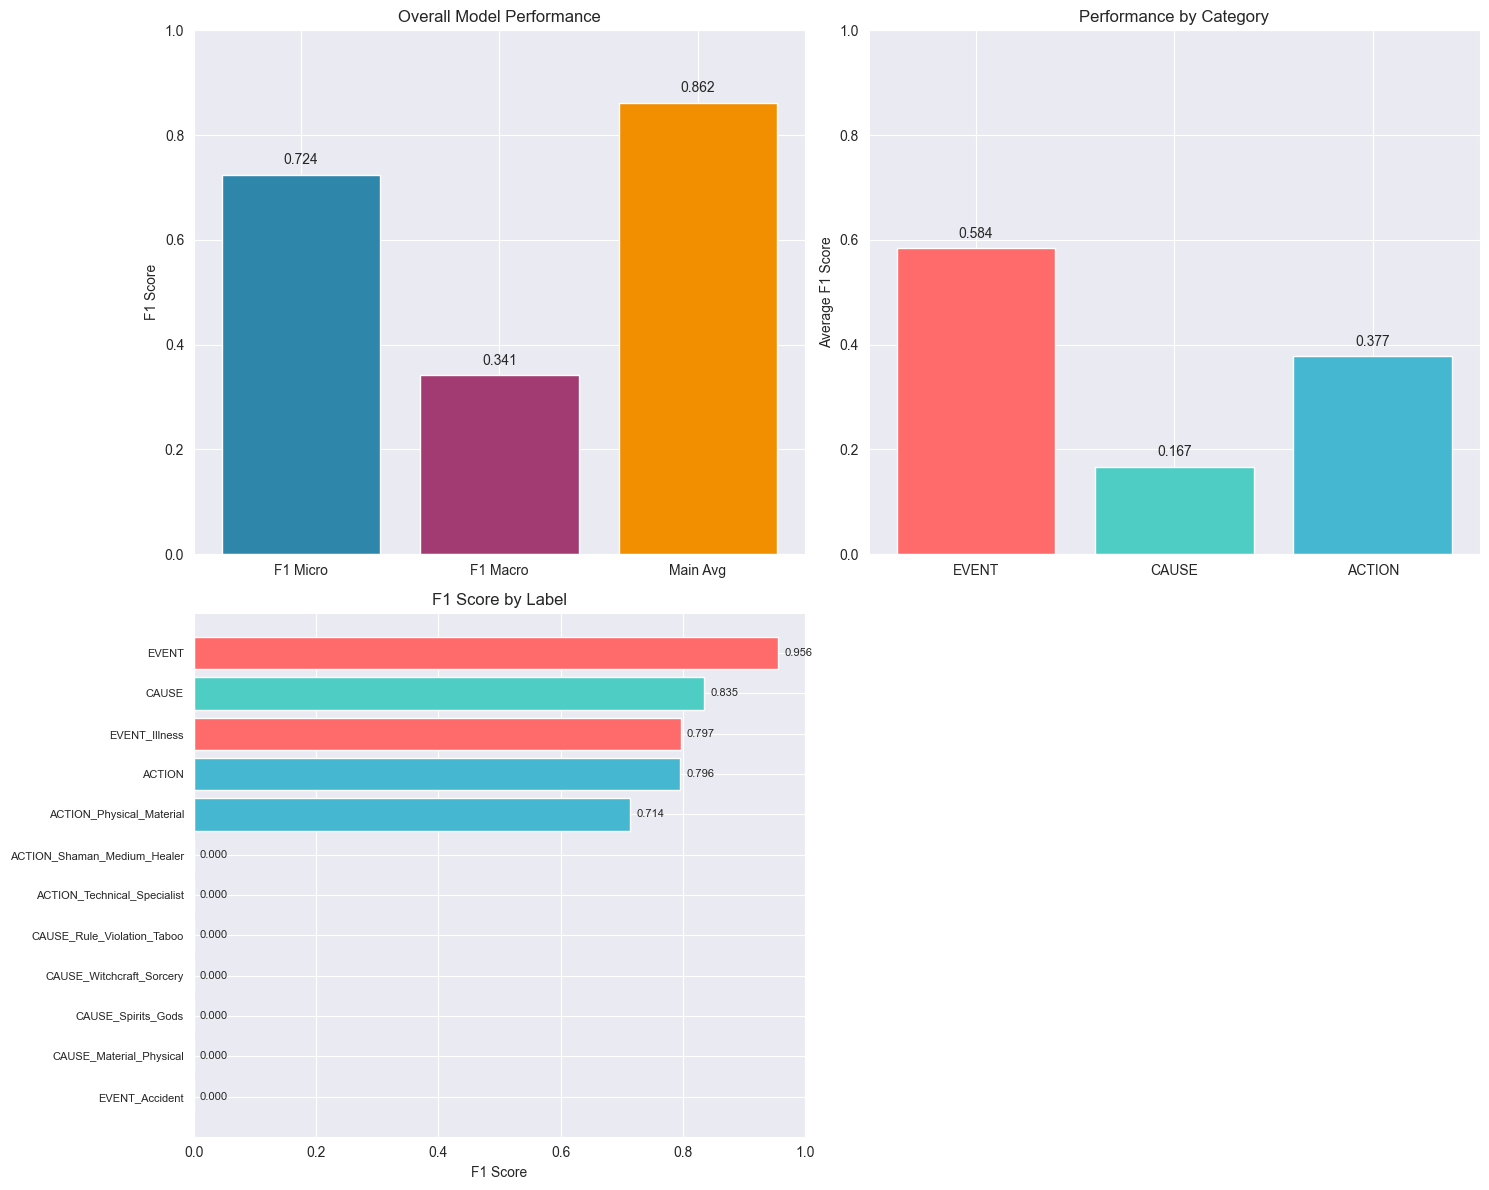

Visualization saved to ./results/Test_for_Huggingface_registry/performance_visualization.png


In [60]:
# ============================================================================
# CELL 16: VISUALIZE RESULTS
# ============================================================================

def visualize_results(test_results, label_columns):
    """Create visualizations of model performance"""

    # Extract F1 scores per label
    label_f1s = {}
    for key, value in test_results.items():
        if key.startswith('eval_f1_') and key not in ['eval_f1_micro', 'eval_f1_macro', 'eval_f1_main_avg']:
            label_name = key.replace('eval_f1_', '')
            label_f1s[label_name] = value

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall Performance
    ax = axes[0, 0]
    metrics = ['F1 Micro', 'F1 Macro', 'Main Avg']
    values = [
        test_results['eval_f1_micro'],
        test_results['eval_f1_macro'],
        test_results['eval_f1_main_avg']
    ]
    bars = ax.bar(metrics, values, color=['#2E86AB', '#A23B72', '#F18F01'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1 Score')
    ax.set_title('Overall Model Performance')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)

    # 2. Per-Category Performance
    ax = axes[0, 1]
    categories = ['EVENT', 'CAUSE', 'ACTION']
    category_scores = {}

    for cat in categories:
        cat_labels = [l for l in label_f1s.keys() if l.startswith(cat)]
        if cat_labels:
            category_scores[cat] = np.mean([label_f1s[l] for l in cat_labels])

    if category_scores:
        bars = ax.bar(category_scores.keys(), category_scores.values(),
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        ax.set_ylim(0, 1)
        ax.set_ylabel('Average F1 Score')
        ax.set_title('Performance by Category')
        for bar, val in zip(bars, category_scores.values()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=10)

    # 3. All Labels Performance
    ax = axes[1, 0:2].flatten()[0]
    axes[1, 1].remove()  # Remove the extra subplot

    labels = list(label_f1s.keys())
    scores = list(label_f1s.values())

    # Sort by score
    sorted_items = sorted(zip(labels, scores), key=lambda x: x[1])
    labels, scores = zip(*sorted_items)

    # Color based on category
    colors = []
    for label in labels:
        if label.startswith('EVENT'):
            colors.append('#FF6B6B')
        elif label.startswith('CAUSE'):
            colors.append('#4ECDC4')
        elif label.startswith('ACTION'):
            colors.append('#45B7D1')
        else:
            colors.append('#95A5A6')

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, scores, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('F1 Score')
    ax.set_title('F1 Score by Label')
    ax.set_xlim(0, 1)

    # Add score values
    for i, (label, score) in enumerate(zip(labels, scores)):
        ax.text(score + 0.01, i, f'{score:.3f}',
                va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/performance_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Visualization saved to {output_dir}/performance_visualization.png")

# Create visualizations
visualize_results(test_results, label_columns)

In [61]:
# ============================================================================
# CELL 17: SAVE FINAL MODEL (HUGGING FACE COMPATIBLE)
# ============================================================================

# Save the model using Hugging Face's save_pretrained
final_model_path = f"{output_dir}/final_model"

# Save model and config
model.save_pretrained(final_model_path)

# Save tokenizer
tokenizer.save_pretrained(final_model_path)

# Save additional training information
additional_info = {
    "label_structure": LABEL_STRUCTURE,
    "training_config": TRAINING_CONFIG,
    "data_config": DATA_CONFIG,
    "optimal_thresholds": {k: {sub_k: float(sub_v) if isinstance(sub_v, (np.float32, np.float64)) else sub_v
                               for sub_k, sub_v in v.items()}
                          for k, v in optimal_thresholds.items()},
    "test_results": {k: float(v) if isinstance(v, (np.float32, np.float64)) else v
                     for k, v in test_results.items()},
    "class_weights": class_weights.tolist() if isinstance(class_weights, torch.Tensor) else class_weights
}

with open(f"{final_model_path}/training_info.json", "w") as f:
    json.dump(additional_info, f, indent=2)

print(f"✅ Model saved to: {final_model_path}")
print(f"✅ You can now load this model with:")
print(f"   model = AutoModel.from_pretrained('{final_model_path}')")
print(f"   tokenizer = AutoTokenizer.from_pretrained('{final_model_path}')")

✅ Model saved to: ./results/Test_for_Huggingface_registry/final_model
✅ You can now load this model with:
   model = AutoModel.from_pretrained('./results/Test_for_Huggingface_registry/final_model')
   tokenizer = AutoTokenizer.from_pretrained('./results/Test_for_Huggingface_registry/final_model')


In [62]:
# ============================================================================
# CELL 18: TEST LOADING THE MODEL
# ============================================================================

# Clear the model from memory
del model

# Load the model using Hugging Face's Auto classes
from transformers import AutoTokenizer

# First register the classes if loading in a new session
AutoConfig.register("configurable_hierarchical", ConfigurableHierarchicalConfig)
AutoModel.register(ConfigurableHierarchicalConfig, ConfigurableHierarchicalModel)

# Load model and tokenizer
loaded_model = AutoModel.from_pretrained(final_model_path)
loaded_tokenizer = AutoTokenizer.from_pretrained(final_model_path)

print("✅ Model successfully loaded using AutoModel!")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 77b5168e-0e51-4706-9947-240977567f64)')' thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model successfully loaded using AutoModel!


In [63]:
# ============================================================================
# CELL 19: QUICK INFERENCE FUNCTION
# ============================================================================

def predict_passage(text, model, tokenizer, label_names, thresholds=None):
    """Quick function to predict labels for a new passage"""

    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(model.device)

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    # Apply thresholds
    if thresholds:
        predictions = {
            label: float(probs[i]) > thresholds.get(label, {}).get('threshold', 0.5)
            for i, label in enumerate(label_names)
        }
    else:
        predictions = {
            label: float(probs[i]) > 0.5
            for i, label in enumerate(label_names)
        }

    # Get probabilities
    prob_dict = {
        label: float(probs[i])
        for i, label in enumerate(label_names)
    }

    # Print results
    print(f"Predictions for: '{text[:100]}...'")
    print("\nPredicted Labels:")
    for label, pred in predictions.items():
        if pred:
            print(f"  ✓ {label} ({prob_dict[label]:.3f})")

    return predictions, prob_dict

# Test the inference function
test_text = "He broke his leg after crossing into the forbidden forest and being cursed by the forest spirits. His leg wouldn't heal, until he finally went to the local shaman and performed the healing ritual."
predictions, probabilities = predict_passage(
    test_text,
    model,
    tokenizer,
    label_columns,
    optimal_thresholds
)

NameError: name 'model' is not defined